In [1]:
import numpy as np
import pandas as pd

import seaborn
from matplotlib import pyplot

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize

from sklearn.cluster import KMeans
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

#from wordcloud import WordCloud, STOPWORDS
import string
from matplotlib import pyplot as plt

import duckdb
import matplotlib.dates as mdates

In [6]:
meta_df = pd.read_csv("aggregate_smb_leaders.csv")

In [ ]:
meta_df

,variable,value,pop,logged_iso2,mean_w,se_w,count,question_n,question_text
0,bus_chl_government_regulations,"Checked: Government regulations (e.g., complia...",smb business leaders,AE,0.124699,0.044790,11.0,88.0,What are the most important challenges your bu...
1,bus_chl_government_regulations,"Unchecked: Government regulations (e.g., compl...",smb business leaders,AE,0.875301,0.044790,77.0,88.0,What are the most important challenges your bu...
2,bus_chl_government_regulations,"Checked: Government regulations (e.g., complia...",smb business leaders,AL,0.090394,0.036841,16.0,141.0,What are the most important challenges your bu...
3,bus_chl_government_regulations,"Unchecked: Government regulations (e.g., compl...",smb business leaders,AL,0.909606,0.036841,125.0,141.0,What are the most important challenges your bu...
4,bus_chl_government_regulations,"Checked: Government regulations (e.g., complia...",smb business leaders,AO,NaN,NaN,NaN,NaN,What are the most important challenges your bu...
...,...,...,...,...,...,...,...,...,...
19771,sup_typ,"Information, technical assistance, or advisory...",smb business leaders,ZM,0.047053,0.013410,17.0,336.0,"Thinking about the past 12 months, what types ..."
19772,sup_typ,Non-repayable grants or subsidies,smb business leaders,ZM,0.074498,0.016629,27.0,336.0,"Thinking about the past 12 months, what types ..."
19773,sup_typ,Other type of government support,smb business leaders,ZM,0.062785,0.015362,23.0,336.0,"Thinking about the past 12 months, what types ..."
19774,sup_typ,"Payment deferrals (e.g., on taxes or rents)",smb business leaders,ZM,0.034816,0.011609,12.0,336.0,"Thinking about the past 12 months, what types ..."


In [20]:
questions = ["s this business currently both operating and engaged in revenue generating activities?", 
             "How long ago did this business begin operations?",
             "Does your business currently use the services of a bank or any other financial institution? By services, we mean services such as those used to save money, make or receive payments and wages, or to receive financial help.",
             "Within the past 12 months, did your business apply for any new lines of credit or loans?",
             "Did your business ever have an outstanding line of credit or loan within the past 3 years?",
             "In the next 12 months, does your business plan to make any large new investments (e.g., machinery and equipment, new or expanded facilities, or research and development projects)?",
             "Thinking about the past 12 months, what types of government support did this business receive?",
             "In which economic sector does this business operate?",
             "What are the most important challenges your business currently faces? (Please select up to two)"
             ]

questions_sql = ', '.join(f"'{q}'" for q in questions)

query = f"""
SELECT *
    FROM meta_df
    WHERE "logged_iso2" = 'US'
        AND "question_text" IN ({questions_sql})
"""
meta_us_df = duckdb.execute(query).df()

In [33]:
query = """
SELECT 
    REPLACE("value", 'Checked: ', '') AS value_label,
    "mean_w"
FROM meta_us_df
WHERE "logged_iso2" = 'US'
  AND "question_text" = 'What are the most important challenges your business currently faces? (Please select up to two)'
  AND "value" LIKE 'Checked: %'
"""

query = """
SELECT 
    REPLACE("value", 'Checked: ', '') AS value_label,
    "mean_w"
FROM challenge_df
WHERE "value" LIKE 'Checked: %'
"""
plot_df = duckdb.execute(query).df()

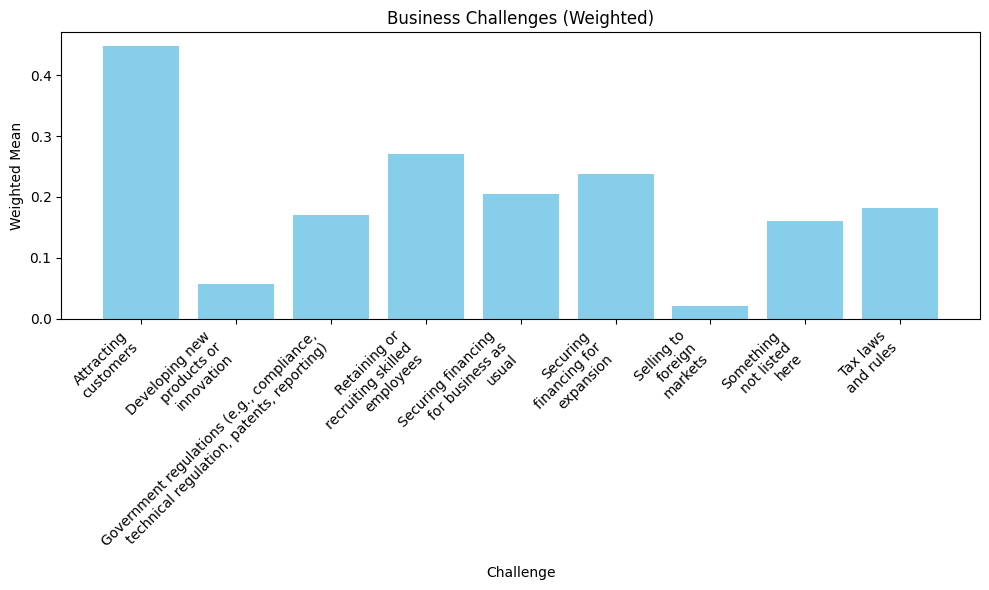

In [37]:
import textwrap

# Sort the DataFrame alphabetically by value_label
plot_df = plot_df.sort_values('value_label')

# Wrap each label into two lines
wrapped_labels = [ "\n".join(textwrap.wrap(label, width=int(len(label)/2))) 
                   for label in plot_df['value_label'] ]

# Plot horizontal bar chart (works better with long labels)
plt.figure(figsize=(10,6))
plt.bar(wrapped_labels, plot_df['mean_w'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Challenge")
plt.ylabel("Weighted Mean")
plt.title("Business Challenges (Weighted)")
plt.tight_layout()
plt.show()